In [190]:
import pandas as pd 
import matplotlib.pyplot as plt

In [191]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [192]:
# identify
# number of rows 
print(f"Number of Rows: {df.shape[0]}")
# number of columns
print(f"Number of Columns: {df.shape[1]}")
# Data types of all columns
print(f"Data types of all columns: \n{df.dtypes}")
#Numerical features
print(f"Numeric Features: {df.select_dtypes(include=['int64', 'float64']).columns}")
# Categorical Features
print(f"Categorical Features: {df.select_dtypes(include='object').columns}")
# Unique Features
unique_features = [cols for cols in df.columns if df[cols].is_unique]
print(f"Unique Features: {unique_features}")


Number of Rows: 8807
Number of Columns: 12
Data types of all columns: 
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
Numeric Features: Index(['release_year'], dtype='object')
Categorical Features: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
Unique Features: ['show_id', 'title']


### Dataset Duration

The Netflix Movies and TV Shows dataset contains information about content available on Netflix, including movies and television shows.

The dataset includes attributes such as:

- Show ID
- Type of content (Movie or TV Show)
- Title
- Director
- Cast members
- Country of production
- Date added to Netflix
- Release year
- Content rating
- Duration
- Listed_in
- Description

The dataset can be used to analyze Netflix's content distribution, production trends, ratings, and genre preferences.

## Data Cleaning

In [ ]:
missing_values = df.columns[df.isna().sum()>0]
print(f"Column with missing values: {missing_values}")
sum_missing_values = df.isna().sum() 
print(f"Number of missing values per column: \n{sum_missing_values}")

Column with missing values: Index(['director', 'cast', 'country', 'date_added', 'rating', 'duration'], dtype='object')
Number of missing values per column: 
Index(['director', 'cast', 'country', 'date_added', 'rating', 'duration'], dtype='object')


In [ ]:
# Check the percentage of missing value per column to determine what to do with the missing value
df.isna().sum()/len(df) *100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [195]:
# filling the missing value in director with unknown since we have very high number of missing value in director
df['director'] = df['director'].fillna('Unknown')

In [196]:
# filling the missing value in cast with Not Available
df['cast'] = df['cast'].fillna('Not Available')

In [197]:
# filling the missing values in country with the most frequent country
country_mode = df['country'].mode()[0]
print(country_mode)
df['country'] = df['country'].fillna(country_mode)

United States


In [198]:
# droping missing values in date_added column

df = df.dropna(subset=['date_added'])

In [199]:
rating_mode = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(rating_mode)

In [200]:
# drop empty column in duration
df = df.dropna(subset=['duration'])


### Handling Missing Values

The following actions were taken to address missing values:

- Missing values in the `director` column were replaced with "Unknown" because removing records would result in unnecessary data loss.
- Missing values in the `cast` column were replaced with "Not Available"ecause removing records would result in unnecessary data loss.
- Missing values in the `country` column were filled using the most frequent country in the dataset.
- Records with missing `date_added` values were removed because the missing dates could not be reliably inferred.
- Missing values in the `rating` column were filled using the mode of the column.
- The missing values in the `duration` column were dropped because there were very little


These approache minimize information loss.

In [201]:
#duplicate records
duplicated_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicated_rows}")

Number of duplicate rows: 0


We have 0 duplicate rows in the record

In [ ]:
# standardization
# remove unnecessary space from date_added column
df['date_added'] =df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

In [205]:
# Text format
df['type'] = df['type'].str.strip().str.title()
df['title']= df['title'].str.strip()
df['director'] = df['director'].str.strip().str.title()
df['cast'] = df['cast'].str.strip().str.title()
df['country'] = df['country'].str.strip().str.title()
df['listed_in'] = df['listed_in'].str.strip().str.title()
df['description'] = df['description'].str.strip().str.capitalize()

In [206]:
# column names
df.columns = df.columns.str.strip().str.title()

In [207]:
# data types
df.dtypes


Show_Id                 object
Type                    object
Title                   object
Director                object
Cast                    object
Country                 object
Date_Added      datetime64[ns]
Release_Year             int64
Rating                  object
Duration                object
Listed_In               object
Description             object
dtype: object

In [208]:
# data validation
print(df['Type'].unique())
len(df['Type'])

['Movie' 'Tv Show']


8794

In [209]:
valid_types = ['Movie', 'Tv Show']

invalid_types = df[
   ~df['Type'].isin(valid_types)
]

print("Invalid content types:", len(invalid_types))

Invalid content types: 0


In [210]:
# check for duplicated titles
duplicate_titles = df[
    df.duplicated(
        subset=['Title'],
        keep=False
    )
]

print("Duplicate titles:",
      duplicate_titles['Title'].nunique())

Duplicate titles: 1


In [211]:
print(df['Rating'].unique())

['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' 'TV-Y7-FV' 'UR']


In [212]:
cleaning_summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values',
        'Duplicates',
        'Invalid Entries',
        'Standardization'
    ],

    'Action Taken': [
        'Filled or removed missing values appropriately',
        'No duplicates found',
        'Removed blank space from dates using strip() function',
        'Converted the data types of each column to either title case or capitalized case appropriately'
    ]
})

print(cleaning_summary)

       Issue Found                                       Action Taken
0   Missing Values     Filled or removed missing values appropriately
1       Duplicates                                No duplicates found
2  Invalid Entries  Removed blank space from dates using strip() f...
3  Standardization  Converted the data types of each column to eit...


## Exploratory Data Analysis(EDA)

In [213]:
df.describe()

,Date_Added,Release_Year
count,8794,8794.000000
mean,2019-05-17 13:29:44.034568960,2014.183534
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.823527


In [214]:
# summary statistics
summary_stats = pd.DataFrame({
    'Mean': [df['Release_Year'].mean()],
    'Median': [df['Release_Year'].median()],
    'Minimum': [df['Release_Year'].min()],
    'Maximum': [df['Release_Year'].max()],
    'Standard Deviation': [df['Release_Year'].std()]
}, index=['Release_Year'])

print(summary_stats)

                     Mean  Median  Minimum  Maximum  Standard Deviation
Release_Year  2014.183534  2017.0     1925     2021            8.823527


In [ ]:
# Data patterns
# Movies vs TV shows distribution
content_distribution = df['Type'].value_counts(normalize=True)

print(f"Movies vs TV shows distribution: {content_distribution.iloc[0]} :{content_distribution.iloc[1]}")


Movies vs TV shows distribution: 0.6968387536957016 :0.30316124630429836


In [216]:
# content added by year
df['added_year'] = df['Date_Added'].dt.year
print(f"Content added by year: \n{df['added_year'].value_counts().sort_index()}")

Content added by year: 
added_year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


In [218]:
# Top content producing countries
country_counts = (
    df['Country']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

print(country_counts)

Country
United States     4510
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [219]:
# Most common ratings

common_rating = df['Rating'].value_counts().head(5)
print(f"Most Common ratings: {common_rating}")

Most Common ratings: Rating
TV-MA    3209
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64


In [220]:
# Most common genres/categories
categories_count = (
    df['Listed_In']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

print(categories_count)

Listed_In
International Movies        2752
Dramas                      2427
Comedies                    1674
International Tv Shows      1350
Documentaries                869
Action & Adventure           859
Tv Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


## Data Visualization



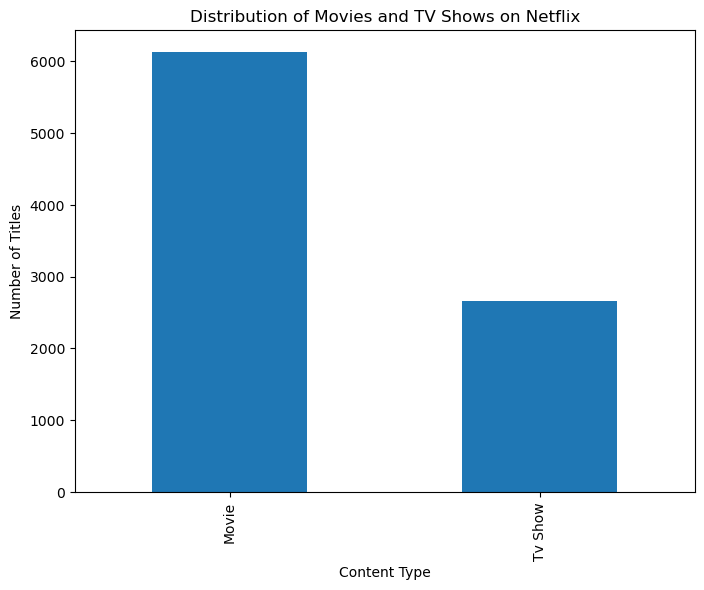

In [221]:
# Bar chart
content_distribution = df['Type'].value_counts()

plt.figure(figsize=(8, 6))
content_distribution.plot(kind='bar')

plt.title('Distribution of Movies and TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

The chart shows the distribution of Movies and TV Shows available on Netflix. This helps understand Netflix's content focus. Movie is the highest

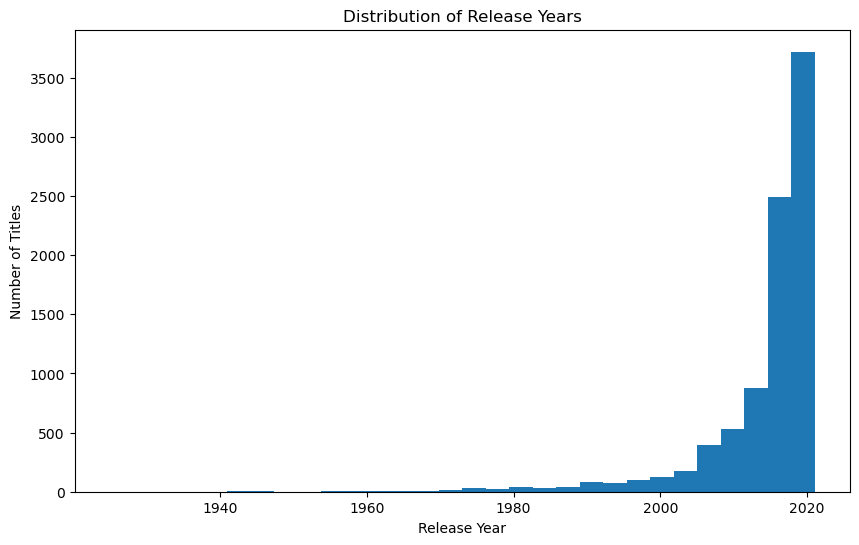

In [222]:
# Histogram
plt.figure(figsize=(10, 6))

plt.hist(df['Release_Year'], bins=30)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

The histogram shows how Netflix content is distributed across release years, indicating whether the platform focuses more on recent or older titles. 2020 has the highest number of realease year

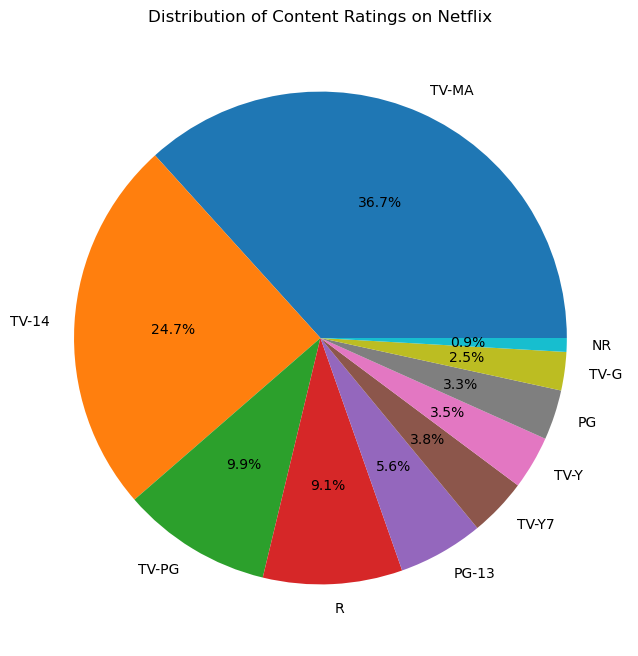

In [223]:
# pie chart
rating_counts = df['Rating'].value_counts().head(10)

plt.figure(figsize=(8, 8))

plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Content Ratings on Netflix')

plt.show()

The pie chart shows the proportion of content ratings, providing insights into Netflix's target audience demographics. TV-MA has the highest rating of 36.7%

In [224]:
df['added_year'].value_counts()

added_year
2019    2016
2020    1879
2018    1649
2021    1498
2017    1187
2016     427
2015      82
2014      24
2011      13
2013      11
2012       3
2009       2
2008       2
2010       1
Name: count, dtype: int64

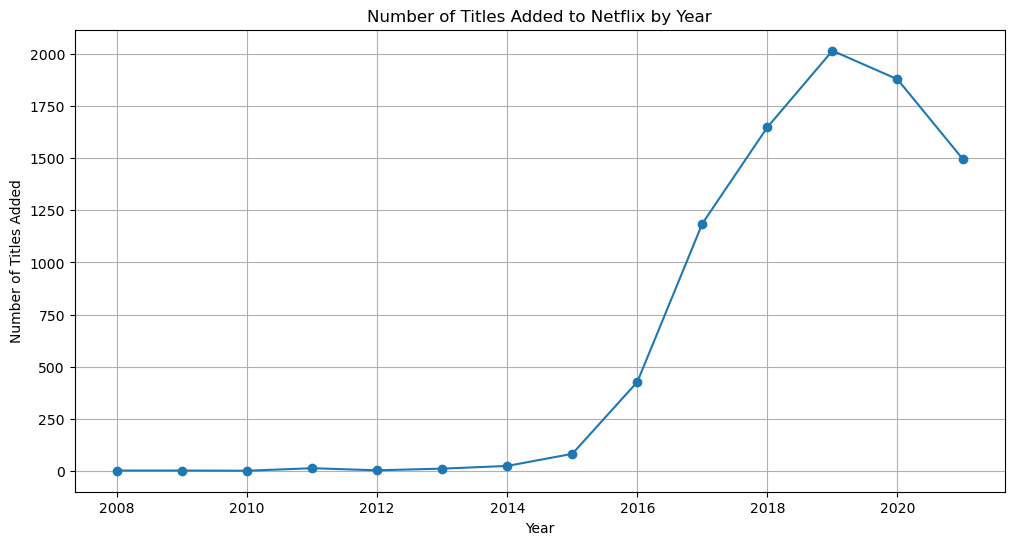

In [225]:
# Line Chart 
content_by_year = (
   df['added_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
content_by_year.plot(kind='line', marker='o')

plt.title('Number of Titles Added to Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.grid(True)
plt.show()

The line chart illustrates Netflix's content growth over time and highlights periods of rapid expansion. 2019 has the highest amount of title added to netflix


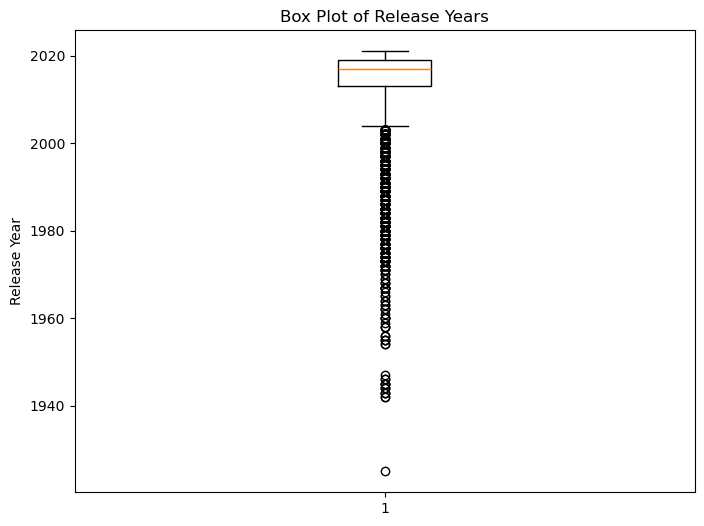

In [226]:
# Box plot
plt.figure(figsize=(8, 6))

plt.boxplot(df['Release_Year'])

plt.title('Box Plot of Release Years')
plt.ylabel('Release Year')

plt.show()

The box plot of release years reveals the distribution of Netflix content over time. The presence of outliers indicates that Netflix hosts some older titles, while the majority of content consists of more recently released movies and TV shows.

## Insights

- Movies constituted a larger proportion of Netflix's catalog compared to TV Shows, indicating a stronger emphasis on movie content.
- United States emerged as the largest content-producing country, contributing the highest number of titles to Netflix.
-  The number of titles added to Netflix increased significantly in 2019, reflecting the platform's expansion strategy.
- The most common content rating was TV\MA, suggesting that Netflix primarily targets audiences.
- International Movies was identified as the most prevalent genre, indicating strong viewer demand and content investment in this category.


In [227]:
df.to_csv('netflix_titles_cleaned_data.csv')